<a href="https://colab.research.google.com/github/emrizky1/machine-learning/blob/main/JS05/JS05_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('voice.csv')
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2534, 20)
Testing data: (634, 20)


In [2]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9763406940063092

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.97      0.98       317
        male       0.97      0.99      0.98       317

    accuracy                           0.98       634
   macro avg       0.98      0.98      0.98       634
weighted avg       0.98      0.98      0.98       634



---
## 2

In [5]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

feature_scores = []

for feature in X.columns:
  model = Pipeline([
      ("scaler", StandardScaler()),
      ("knn", KNeighborsClassifier(n_neighbors=5))
  ])

  scores = cross_val_score(model, X_train[[feature]], y_train, cv=cv, scoring="accuracy")
  feature_scores.append((feature, scores.mean()))

feature_scores = sorted(feature_scores, key=lambda x: x[1], reverse=True)
for feature, score in feature_scores:
  print(f"{feature}: {score:.4f}")

meanfun: 0.9408
IQR: 0.8990
Q25: 0.8662
sd: 0.7837
sp.ent: 0.7167
mode: 0.6634
sfm: 0.6610
maxdom: 0.6243
mindom: 0.6176
skew: 0.6164
meanfreq: 0.6113
centroid: 0.6113
dfrange: 0.6026
median: 0.5888
meandom: 0.5817
kurt: 0.5608
minfun: 0.5407
maxfun: 0.5217
modindx: 0.5099
Q75: 0.5028


---
## 3

In [7]:
selected_features = [
    "IQR",
    "skew",
    "sfm",
    "mode",
    "meanfun"
]

In [8]:
k_values = range(1, 21)

cv_accuracy = []
training_accuracy = []

for k in k_values:

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])

    model.fit(
        X_train[selected_features],
        y_train
    )

    train_pred = model.predict(
        X_train[selected_features]
    )

    training_accuracy.append(
        accuracy_score(y_train, train_pred)
    )

    scores = cross_val_score(
        model,
        X_train[selected_features],
        y_train,
        cv=cv,
        scoring="accuracy"
    )

    cv_accuracy.append(scores.mean())

best_k = k_values[np.argmax(cv_accuracy)]

print("Best k:", best_k)
print("Best CV accuracy:", max(cv_accuracy))

Best k: 4
Best CV accuracy: 0.9814494312822072


In [9]:
final_model = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=4))
])

final_model.fit(
    X_train[selected_features],
    y_train
)

y_pred = final_model.predict(
    X_test[selected_features]
)

print("Test Accuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Test Accuracy: 0.9873817034700315

Confusion Matrix:
[[313   4]
 [  4 313]]

Classification Report:
              precision    recall  f1-score   support

      female       0.99      0.99      0.99       317
        male       0.99      0.99      0.99       317

    accuracy                           0.99       634
   macro avg       0.99      0.99      0.99       634
weighted avg       0.99      0.99      0.99       634



---
## Analysis

1. Which features did you employ to obtain the best results?
  - meanfun was the strongest individual feature, while the combinations of the five features provided better classification performance.

3. What is the best k value?
  - k = 4 with 98.74% test accuracy

---

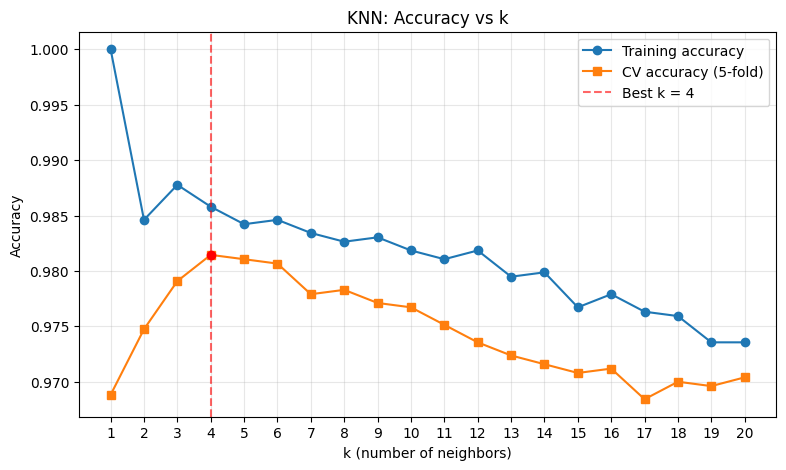

In [10]:
plt.figure(figsize=(9, 5))

plt.plot(k_values, training_accuracy, marker="o", label="Training accuracy")
plt.plot(k_values, cv_accuracy, marker="s", label="CV accuracy (5-fold)")

plt.axvline(best_k, color="red", linestyle="--", alpha=0.6, label=f"Best k = {best_k}")
plt.scatter(best_k, max(cv_accuracy), color="red", zorder=5)

plt.xticks(k_values)
plt.xlabel("k (number of neighbors)")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs k")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

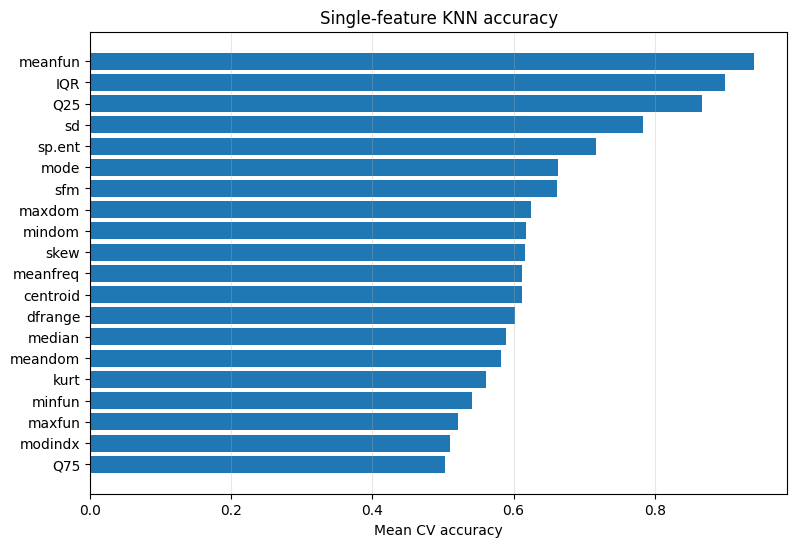

In [11]:
features, scores = zip(*feature_scores)

plt.figure(figsize=(9, 6))
plt.barh(features[::-1], scores[::-1])
plt.xlabel("Mean CV accuracy")
plt.title("Single-feature KNN accuracy")
plt.grid(axis="x", alpha=0.3)
plt.show()